In [1]:
import json
# Load tool metadata from your uploaded JSON
try:
    with open('data/galaxy_tools_may_3_2025_v1.json', 'r') as f:
        tools = json.load(f)

    print(f"Loaded {len(tools)} tools.")
except FileNotFoundError:
    print("Error: The file '/content/galaxy_tools_may_3_2025_v1.json' was not found.")
    print("Please upload the file or check the file path.")
    tools = []

Loaded 13884 tools.


In [ ]:
training_data = []

for tool in tools:
    name = tool.get("name", "")
    description = tool.get("description", "")
    help_text = tool.get("help", "")
    category = tool.get("category", "")

    # Construct a tool passage representation
    tool_passage = f"{name}. {description}. {help_text}".strip().replace("\n", " ")

    if not tool_passage or len(tool_passage.split()) < 10:
        continue

    # Create synthetic queries
    queries = [
        f"How can I {name.lower()}?",
        f"Which tool can be used to {name.lower()}?",
        f"{category.lower()} task: {name.lower()}" if category else f"task: {name.lower()}", # Add a check for None
        f"I want to {name.lower()} in Galaxy",
        f"Tool for {description.lower()}" if description else f"Task: {name.lower()}"
    ]

    for query in queries:
        training_data.append({"query": "query" + query,
            "passage": "passage" + tool_passage
        })

In [3]:
with open("data/e5_tool_train_pairs.jsonl", "w") as f:
    for item in training_data:
        json.dump(item, f)
        f.write("\n")
print(f"Saved {len(training_data)} training pairs.")

Saved 68840 training pairs.


In [4]:
from sentence_transformers import SentenceTransformer, util
import json
import random
import torch

/home/john/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-19 20:26:31.618631: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-19 20:26:32.235012: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752945992.502713   62282 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752945992.573098   62282 cuda_blas.cc:1407] Unable t

In [5]:
# Filter and preprocess
valid_tools = []
for tool in tools:
    name = tool.get("name", "")
    help_text = tool.get("help", "")
    if name and help_text and len(help_text.split()) > 10:
        # Move the replace call outside the f-string
        cleaned_help_text = help_text.replace('\n', ' ')
        full_text = f"{name}. {cleaned_help_text}"
        valid_tools.append({
            "name": name,
            "text": full_text
        })

print(f"Total valid tools: {len(valid_tools)}")

Total valid tools: 13364


In [6]:
model = SentenceTransformer("intfloat/e5-base-v2")
tool_texts = [t["text"] for t in valid_tools]
tool_embeddings = model.encode(tool_texts, normalize_embeddings=True, convert_to_tensor=True)

In [7]:
triplets = []

for i, tool in enumerate(valid_tools):
    anchor_query = f"How can I {tool['name'].lower()}?"
    pos_text = tool["text"]
    anchor_emb = model.encode(f"query: {anchor_query}", normalize_embeddings=True, convert_to_tensor=True)

    # Compute similarities
    similarities = util.cos_sim(anchor_emb, tool_embeddings)[0]
    sorted_indices = torch.argsort(similarities, descending=True)

    # Skip the top one (it's usually the correct one)
    for j in sorted_indices[1:]:
        neg_text = valid_tools[j]["text"]
        if neg_text != pos_text:
            triplets.append({
                "anchor": anchor_query,
                "positive": pos_text,
                "negative": neg_text
            })
            break 

print(f"Generated {len(triplets)} triplets.")

Generated 13364 triplets.


In [8]:
with open("data/e5_triplet_training.jsonl", "w") as f:
    for triplet in triplets:
        json.dump(triplet, f)
        f.write("\n")

In [12]:
import json

# Load pair data
pair_data = []
with open('data/e5_tool_train_pairs.jsonl', 'r') as f:
    for line in f:
        pair_data.append(json.loads(line))

# Load triplet data
triplet_data = []
with open('data/e5_triplet_training.jsonl', 'r') as f:
    for line in f:
        triplet_data.append(json.loads(line))


print("Pair sample:", pair_data[0])
print("Triplet sample:", triplet_data[0])

Pair sample: {'query': 'query: How can I ncbi datasets genomes?', 'passage': 'passage: NCBI Datasets Genomes. import data from the NCBI Datasets Genomes page. None'}
Triplet sample: {'anchor': 'How can I upload file?', 'positive': 'Upload File. **Auto-detect**  The system will attempt to detect Axt, Fasta, Fastqsolexa, Gff, Gff3, Html, Lav, Maf, Tabular, Wiggle, Bed and Interval (Bed with headers) formats. If your file is not detected properly as one of the known formats, it most likely means that it has some format problems (e.g., different number of columns on different rows). You can still coerce the system to set your data to the format you think it should be.  You can also upload compressed files, which will automatically be decompressed.  -----  **Ab1**  A binary sequence file in \'ab1\' format with a \'.ab1\' file extension.  You must manually select this \'File Format\' when uploading the file.  -----  **Axt**  blastz pairwise alignment format.  Each alignment block in an axt f

In [15]:
from sentence_transformers import SentenceTransformer, losses, InputExample, models
from torch.utils.data import DataLoader

model_name = "intfloat/e5-base-v2"
model = SentenceTransformer(model_name)

In [17]:
pair_train_samples = [
    InputExample(texts=[item["query"], item["passage"]]) for item in pair_data
]

pair_train_dataloader = DataLoader(pair_train_samples, shuffle=True, batch_size=16)
pair_loss = losses.MultipleNegativesRankingLoss(model)

In [18]:
triplet_train_samples = [
    InputExample(texts=[item["anchor"], item["positive"], item["negative"]])
    for item in triplet_data
]

triplet_train_dataloader = DataLoader(triplet_train_samples, shuffle=True, batch_size=16)
triplet_loss = losses.TripletLoss(model=model)

In [19]:
model.fit(
    train_objectives=[(pair_train_dataloader, pair_loss)],
    epochs=4,
    warmup_steps=100,
    output_path='models/e5-galaxy-finetuned'
)

Step,Training Loss
500,0.092100
1000,0.006600
1500,0.006200
2000,0.008100
2500,0.007300
3000,0.009100
3500,0.005300
4000,0.008300
4500,0.007300
5000,0.005900


## Benchmarking our model

In [37]:
import json
from collections import defaultdict

# Load tool metadata
with open("data/galaxy_tools_may_3_2025_v1.json", "r") as f:
    tools = json.load(f)

print(f"Loaded {len(tools)} tools.")

Loaded 13884 tools.


In [3]:
import numpy as np
import json
from sentence_transformers import SentenceTransformer, util

def compute_recall_at_k(model_path, embeddings_path, metadata_path, queries, ground_truth, k=5):
    # Load pre-computed tool embeddings and metadata
    embeddings = np.load(embeddings_path)
    with open(metadata_path, 'r', encoding='utf-8') as f:
        metadata = json.load(f)

    # Load SentenceTransformer model for encoding queries
    model = SentenceTransformer(model_path)

    total_recall = 0
    recall_scores = []

    for query in queries:
        # Encode the query
        query_embedding = model.encode(query, convert_to_numpy=True)

        # Compute cosine similarity with the tool corpus
        similarities = util.cos_sim(query_embedding, embeddings)[0]

        # Get indices of top-k most similar tools
        top_k_indices = np.argsort(-similarities)[:k]
        top_k_names = [metadata[i]["name"] for i in top_k_indices]

        # Ground truth for this query
        expected_tools = ground_truth.get(query, [])

        # Compute recall: did we find at least one ground truth name in top-k suggestions?
        match_found = any(gt_name in top_k_names for gt_name in expected_tools)
        recall = 1 if match_found else 0
        recall_scores.append(recall)

        print(f"\nQuery: {query}")
        print(f"Expected: {expected_tools}")
        print(f"Top-{k} Suggestions: {top_k_names}")
        print(f"Recall@{k}: {recall}")

        total_recall += recall

    # Compute average recall
    avg_recall = total_recall / len(queries)
    print(f"\n🔍 Average Recall@{k}: {avg_recall:.2f}")

    return recall_scores, avg_recall


/home/john/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-24 10:39:43.580119: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-24 10:39:43.969367: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753342784.120867   45432 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753342784.162786   45432 cuda_blas.cc:1407] Unable t

In [4]:
queries = [
    "MAF Coverage Stats",
    "tool to get Microbial Data",
    "tool to Zip a collection",
    "I want to remove a specified number of lines from the beginning of a dataset", 
    "tools converts a single-channel image to a multi-channel image by repeating the channel multiple times", 
    "This tool converts wiggle data into interval type.",
    "I want tool convert AXT file to a FASTA alignment", 
    "tool to extract and return MAF block from dataset", 
    "In galaxy, i want tool to annotate genome pipeline",
    "tool thst can searches each query sequence in <seqfile>", 

    "Demultiplex raw Illumina reads with barcode correction and quality filtering", 
    "Align reads into exact matching stacks and identify SNPs",                    
    "Run Stacks pipeline using reference-aligned reads",                           
    "Create a catalog of loci from multiple samples",                              
    "Correct genotype and haplotype calls in Stacks pipeline",   

    "Quantify chimeric aligned loci using CRLs and mapped reads",
    "Extract best chimeric alignments from CRL data",
    "Merge overlapping alignment positions into read loci",
    "Map RNA reads to transcriptome using bwa-mem or CLAN",
    "Deduplicate FASTQ reads and output unique sequences",
    "Generate bed and bedgraph from NanoCompore SampComp results",
    "Visualize nanopore sequencing data and alignments",
    "Annotate SARS-CoV-2 variants using SnpEff",
    "Polish nanopore assemblies using neural networks",
    "Run full pipeline for consensus polishing with medaka",
    "tool suite to create a consensus sequence from nanopore data"
]

ground_truth = {
    "MAF Coverage Stats": ["MAF Coverage Stats"], 
    "tool to get Microbial Data": ["Get Microbial Data"],
    "tool to Zip a collection": ["Zip collections"],
    "I want to remove a specified number of lines from the beginning of a dataset": ["Remove beginning"],
    "tools converts a single-channel image to a multi-channel image by repeating the channel multiple times": ["Convert single-channel to multi-channel image"], 
    "This tool converts wiggle data into interval type.": ["Wiggle-to-Interval"],
    "I want tool convert AXT file to a FASTA alignment" : ["AXT to concatenated FASTA"],
    "tool to extract and return MAF block from dataset": ["Extract MAF blocks",'Extract MAF by block number', 'MaveDB', 'Filter MAF blocks', 'Filter MAF blocks'], 
    "In galaxy, i want tool to annotate genome pipeline": ["Maker"],
    "tool thst can searches each query sequence in <seqfile>": ["jackhmmer"], 

    "Demultiplex raw Illumina reads with barcode correction and quality filtering": ["Stacks: process radtags"],
    "Align reads into exact matching stacks and identify SNPs": ["Stacks: ustacks"],
    "Run Stacks pipeline using reference-aligned reads": ["Stacks: reference map"],
    "Create a catalog of loci from multiple samples": ["Stacks: cstacks"],
    "Correct genotype and haplotype calls in Stacks pipeline": ["Stacks: rxstacks"],

    "Quantify chimeric aligned loci using CRLs and mapped reads": ["ChiRA qauntify"],
    "Extract best chimeric alignments from CRL data": ["ChiRA extract"],
    "Merge overlapping alignment positions into read loci": ["ChiRA merge"],
    "Map RNA reads to transcriptome using bwa-mem or CLAN": ["ChiRA map"],
    "Deduplicate FASTQ reads and output unique sequences": ["ChiRA collapse"],
    "Generate bed and bedgraph from NanoCompore SampComp results": ["NanoComporeDB"],
    "Visualize nanopore sequencing data and alignments": ["NanoPlot"],
    "Annotate SARS-CoV-2 variants using SnpEff": ["SnpEff eff:"],
    "Polish nanopore assemblies using neural networks": ["medaka: Consensus"],
    "Run full pipeline for consensus polishing with medaka": ["medaka: Consensus pipeline"],
    "tool suite to create a consensus sequence from nanopore data": ["medaka: Variant pipeline", "Nanopolish variants", 'Nanopolish variants', 'Nanopolish variants', 'Nanopolish variants', 'medaka_consensus']


}

compute_recall_at_k(
    model_path='intfloat/e5-base-v2',
    embeddings_path='embeddings/galaxy_embeddings.npy',
    metadata_path='embeddings/galaxy_metadata.json',
    queries=queries,
    ground_truth=ground_truth,
    k=5
)


Query: MAF Coverage Stats
Expected: ['MAF Coverage Stats']
Top-5 Suggestions: ['Convert MAF to Genomic Intervals', 'Convert MAF to Fasta', 'MAF Coverage Stats', 'MAF Coverage Stats', 'MAF Coverage Stats']
Recall@5: 1

Query: tool to get Microbial Data
Expected: ['Get Microbial Data']
Top-5 Suggestions: ['Get Microbial Data', 'mOTUs_profiler', 'Retrieve ENA taxon data', 'GDCWebApp', 'Phyloseq']
Recall@5: 1

Query: tool to Zip a collection
Expected: ['Zip collections']
Top-5 Suggestions: ['Unzip', 'Zip collections', 'Unzip', 'Unzip collection', 'Collapse Collection']
Recall@5: 1

Query: I want to remove a specified number of lines from the beginning of a dataset
Expected: ['Remove beginning']
Top-5 Suggestions: ['Remove beginning', 'Select first', 'Select first', 'Select first', 'Select first']
Recall@5: 1

Query: tools converts a single-channel image to a multi-channel image by repeating the channel multiple times
Expected: ['Convert single-channel to multi-channel image']
Top-5 Sugges

([1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1],
 0.9230769230769231)

In [ ]:
compute_recall_at_k(
    model_path='models/e5-galaxy-finetuned',
    embeddings_path='embeddings/galaxy_embeddings.npy',
    metadata_path='embeddings/galaxy_metadata.json',
    queries=queries,
    ground_truth=ground_truth,
    k=5
)


Query: MAF Coverage Stats
Expected: ['MAF Coverage Stats']
Top-5 Suggestions: ['Convert MAF to Genomic Intervals', 'Convert MAF to Fasta', 'MAF Coverage Stats', 'MAF Coverage Stats', 'MAF Coverage Stats']
Recall@5: 1

Query: tool to get Microbial Data
Expected: ['Get Microbial Data']
Top-5 Suggestions: ['Get Microbial Data', 'Minfi Get M', 'UCSC Archaea', 'YeastMine', 'BioMart']
Recall@5: 1

Query: tool to Zip a collection
Expected: ['Zip collections']
Top-5 Suggestions: ['Unzip', 'Unzip', 'Zip collections', 'Collapse Collection', 'Collapse Collection']
Recall@5: 1

Query: I want to remove a specified number of lines from the beginning of a dataset
Expected: ['Remove beginning']
Top-5 Suggestions: ['Remove beginning', 'Extract dataset', 'Select first', 'Convert Len file to Linecount', 'Filter collection']
Recall@5: 1

Query: tools converts a single-channel image to a multi-channel image by repeating the channel multiple times
Expected: ['Convert single-channel to multi-channel image']

([1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1],
 0.9230769230769231)

: 

## vague Queries variants to see the model performance over vague queries

In [16]:
ground_truth = {
 "compare multiple funannotated fungal genomes": ['Funannotate compare'],
 "calculate alpha diversity from Bracken output": ['Krakentools: Calculates alpha diversity'], 
 "split stratified HUMAnN output into separate tables": ['Split a HUMAnN table']

}

In [17]:
import json

# Load vague queries
with open("data/vague_queries.json") as f:
    vague_queries_dict = json.load(f)

# Flatten vague queries and create corresponding ground truth mapping
vague_query_list = []
vague_ground_truth = {}

for original_query, variations in vague_queries_dict.items():
    for variation in variations:
        vague_query_list.append(variation)
        vague_ground_truth[variation] = ground_truth[original_query]  # same ground truth

# Run the benchmark on vague queries
compute_recall_at_k(
    model_path='models/e5-galaxy-finetuned',
    embeddings_path='embeddings/galaxy_embeddings.npy',
    metadata_path='embeddings/galaxy_metadata.json',
    queries=vague_query_list,
    ground_truth=vague_ground_truth,
    k=5
)


Query: compare multiple funannotated fungal genomes
Expected: ['Funannotate compare']
Top-5 Suggestions: ['Funannotate compare', 'Funannotate compare', 'Funannotate compare', 'Funannotate compare', 'Funannotate compare']
Recall@5: 1

Query: tool for visualizing differences in genome annotations
Expected: ['Funannotate compare']
Top-5 Suggestions: ['Funannotate compare', 'Funannotate compare', 'Funannotate compare', 'Funannotate compare', 'Funannotate compare']
Recall@5: 1

Query: compare annotations from different Funannotate runs
Expected: ['Funannotate compare']
Top-5 Suggestions: ['Funannotate compare', 'Funannotate compare', 'Funannotate compare', 'Funannotate compare', 'Funannotate compare']
Recall@5: 1

Query: comparative genomics for fungal annotations
Expected: ['Funannotate compare']
Top-5 Suggestions: ['Funannotate compare', 'Funannotate compare', 'Funannotate compare', 'Funannotate compare', 'Funannotate compare']
Recall@5: 1

Query: Funannotate tool to generate comparative

([1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  0,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1],
 0.8333333333333334)

In [19]:
import json

# Load vague queries
with open("data/vague_queries.json") as f:
    vague_queries_dict = json.load(f)

# Flatten vague queries and create corresponding ground truth mapping
vague_query_list = []
vague_ground_truth = {}

for original_query, variations in vague_queries_dict.items():
    for variation in variations:
        vague_query_list.append(variation)
        vague_ground_truth[variation] = ground_truth[original_query]  # same ground truth

# Run the benchmark on vague queries
compute_recall_at_k(
    model_path='intfloat/e5-base-v2',
    embeddings_path='embeddings/galaxy_embeddings.npy',
    metadata_path='embeddings/galaxy_metadata.json',
    queries=vague_query_list,
    ground_truth=vague_ground_truth,
    k=5
)


Query: compare multiple funannotated fungal genomes
Expected: ['Funannotate compare']
Top-5 Suggestions: ['Funannotate compare', 'Funannotate compare', 'Funannotate compare', 'Funannotate compare', 'Funannotate compare']
Recall@5: 1

Query: tool for visualizing differences in genome annotations
Expected: ['Funannotate compare']
Top-5 Suggestions: ['Funannotate compare', 'Funannotate compare', 'Funannotate compare', 'Funannotate compare', 'Funannotate compare']
Recall@5: 1

Query: compare annotations from different Funannotate runs
Expected: ['Funannotate compare']
Top-5 Suggestions: ['Funannotate compare', 'Funannotate compare', 'Funannotate compare', 'Funannotate compare', 'Funannotate compare']
Recall@5: 1

Query: comparative genomics for fungal annotations
Expected: ['Funannotate compare']
Top-5 Suggestions: ['Funannotate compare', 'Funannotate compare', 'Funannotate compare', 'Funannotate compare', 'Funannotate compare']
Recall@5: 1

Query: Funannotate tool to generate comparative

([1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  0,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  0,
  1,
  1],
 0.8)

## Benchmarking our model training 

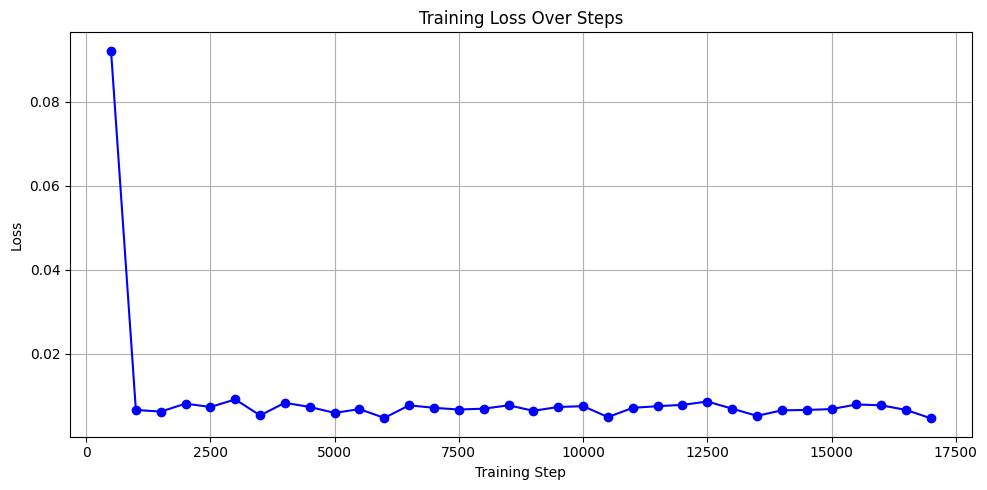

In [ ]:
import matplotlib.pyplot as plt

# Training steps and corresponding loss
steps = [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000,
         5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000,
         10500, 11000, 11500, 12000, 12500, 13000, 13500, 14000, 14500,
         15000, 15500, 16000, 16500, 17000]

loss = [0.0921, 0.0066, 0.0062, 0.0081, 0.0073, 0.0091, 0.0053, 0.0083,
        0.0073, 0.0059, 0.0068, 0.0047, 0.0077, 0.0071, 0.0067, 0.0069,
        0.0077, 0.0064, 0.0073, 0.0075, 0.0049, 0.0071, 0.0075, 0.0078,
        0.0086, 0.0069, 0.0052, 0.0065, 0.0066, 0.0068, 0.0079, 0.0077,
        0.0066, 0.0046]

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(steps, loss, marker='o', linestyle='-', color='blue')
plt.title('Training Loss Over Steps')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()